# PCEP Capstone Project: A Data-Driven Approach to AI and Python
## Transformational AI - Amazon Reviews Analysis

In this project, we analyze Amazon Reviews 2023 datasets to perform data transformation, analysis, and visualization using pandas, matplotlib, and seaborn.

In [1]:
!python3 --version

Python 3.14.3


In [2]:
import sys
print(f"Python version: {sys.version}")

# Verify required libraries
import pandas as pd
import matplotlib
import seaborn as sns
import pyarrow
import datasets

print(f"pandas: {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"pyarrow: {pyarrow.__version__}")
print(f"datasets: {datasets.__version__}")
print("\nAll libraries installed successfully!")

Python version: 3.14.3 (main, Feb  3 2026, 15:32:20) [Clang 16.0.0 (clang-1600.0.26.6)]
pandas: 3.0.1
matplotlib: 3.10.8
seaborn: 0.13.2
pyarrow: 23.0.1
datasets: 4.8.2

All libraries installed successfully!


## Part 2: Download and Analyze the Reviews Dataset
### 2.1 Working with Big Data
We're working with the Amazon Reviews 2023 dataset from Hugging Face. To avoid overloading memory, we'll limit our sample to 100 items.

In [3]:
from datasets import load_dataset
import pandas as pd

# Load the Amazon Electronics Reviews dataset with streaming
# Note: direct HTTP streaming used as trust_remote_code is deprecated
import requests, json

REVIEWS_URL = (
    "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023"
    "/resolve/main/raw/review_categories/Electronics.jsonl"
)

# Set sample limit
sample_limit = 100

# Collect samples using a for loop
reviews_list = []
count = 0
response = requests.get(REVIEWS_URL, stream=True, timeout=60)
for line in response.iter_lines():
    if not line:
        continue
    reviews_list.append(json.loads(line))
    count += 1
    if count >= sample_limit:
        break

# Create DataFrame
reviews_df = pd.DataFrame(reviews_list)
print(f"Successfully loaded {len(reviews_df)} reviews")
print(f"Columns: {list(reviews_df.columns)}")

Successfully loaded 100 reviews
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


In [4]:
# Display the first few rows
reviews_df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,"First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products like I am you will want to pass on these. Second: the phone adapter is useless as-is. Mine was not drilled far enough to be able to tighten it into place for my iPhone 12 max. It just slipped & slid all over. Stupid me putting the adapter together first without picking up the binoculars to smell them bc I wasted 15 minutes trying to figure out how to put the adapter together bc it does not come with instructions! I had to come back here to the website which was a total pain. Third: the tripod is also useless. I would not trust the iOS to hold my $1600 phone nor even a Mattel Barbie for that matter. It’s just inefficient for the job imo. Third: in order to try to give an honest review I did don gloves & eyewear to check the binoculars out. They seemed average except for mine seemed to be missing about 10% of the film costing in the lower edge of one of the lenses which would have ruined every video & photograph unplanned to take so for me these are a very huge hard pass. I expect the accessories that come with the main product to be as good or better than the product I’m buying. Otherwise I would just buy the product as a stand alone. Sadly, I found a decent pair of binoculars last year with a much better quality phone adapter & tripod, but they had a defect too. Guess I’m going to have to pay more. Ugh.","[{'small_image_url': 'https://m.media-amazon.com/images/I/71YN+Qk3kCL._SL256_.jpg', 'medium_image_url': 'https://m.media-amazon.com/images/I/71YN+Qk3kCL._SL800_.jpg', 'large_image_url': 'https://m.media-amazon.com/images/I/71YN+Qk3kCL._SL1600_.jpg', 'attachment_type': 'IMAGE'}]",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,"These didn’t work. Idk if they were damaged in shipping or what, but the lenses were loose or something. I could see half a lens with its edge in the frame and the rest was missing. It looked like it came loose or was broken.",[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,"I love these. They even come with a carry case and several sizes of ear bud inserts. Thank heaven! I get ear pain from most, but the smallest buds fit great. They also have a charger and all of it fits in the carry case. I just wish they came in more colors preferably something bright! When I leave them on my nightstand it takes a while to figure out which of half a dozen black cables are the right ones. Even white would be ok as only my iPhone has a white cord.",[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,"I was searching for a sturdy backpack for school that would allow me to carry my laptop as well as schoolbooks. After reading many of the reviews of this bag, I placed my order and crossed my fingers. I shouldn't have worried; it's a great bag! Solidly built and traveler-friendly with a ton of compartments for every little thing one might need to stow away. While this backpack is slightly larger than your average backpack, it is comfortable to wear trekking cross campus. Also, another aspect of this bag that I love is that it stands upright. I know that sounds kinda crazy, but I find it annoying when your backpack flops over next to your desk and stuff kind of just falls out, or if you need to grab something quickly out of the bag you have to awkwardly curl your body around the side of your chair and then on the way up, smash your head against the desk. So yeah, lazy girl (points to self) loves the convenience of a bag that stands upright for easy grabbage. I plan to travel with this backpack when I fly home this Christmas instead of bringing a bulky tote bag on the plane.",[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,12

In [5]:
# Customize output to show only first 10 items
Items_To_Print = 10
reviews_df.head(Items_To_Print)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,"First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products like I am you will want to pass on these. Second: the phone adapter is useless as-is. Mine was not drilled far enough to be able to tighten it into place for my iPhone 12 max. It just slipped & slid all over. Stupid me putting the adapter together first without picking up the binoculars to smell them bc I wasted 15 minutes trying to figure out how to put the adapter together bc it does not come with instructions! I had to come back here to the website which was a total pain. Third: the tripod is also useless. I would not trust the iOS to hold my $1600 phone nor even a Mattel Barbie for that matter. It’s just inefficient for the job imo. Third: in order to try to give an honest review I did don gloves & eyewear to check the binoculars out. They seemed average except for mine seemed to be missing about 10% of the film costing in the lower edge of one of the lenses which would have ruined every video & photograph unplanned to take so for me these are a very huge hard pass. I expect the accessories that come with the main product to be as good or better than the product I’m buying. Otherwise I would just buy the product as a stand alone. Sadly, I found a decent pair of binoculars last year with a much better quality phone adapter & tripod, but they had a defect too. Guess I’m going to have to pay more. Ugh.","[{'small_image_url': 'https://m.media-amazon.com/images/I/71YN+Qk3kCL._SL256_.jpg', 'medium_image_url': 'https://m.media-amazon.com/images/I/71YN+Qk3kCL._SL800_.jpg', 'large_image_url': 'https://m.media-amazon.com/images/I/71YN+Qk3kCL._SL1600_.jpg', 'attachment_type': 'IMAGE'}]",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,"These didn’t work. Idk if they were damaged in shipping or what, but the lenses were loose or something. I could see half a lens with its edge in the frame and the rest was missing. It looked like it came loose or was broken.",[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,"I love these. They even come with a carry case and several sizes of ear bud inserts. Thank heaven! I get ear pain from most, but the smallest buds fit great. They also have a charger and all of it fits in the carry case. I just wish they came in more colors preferably something bright! When I leave them on my nightstand it takes a while to figure out which of half a dozen black cables are the right ones. Even white would be ok as only my iPhone has a white cord.",[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,"I was searching for a sturdy backpack for school that would allow me to carry my laptop as well as schoolbooks. After reading many of the reviews of this bag, I placed my order and crossed my fingers. I shouldn't have worried; it's a great bag! Solidly built and traveler-friendly with a ton of compartments for every little thing one might need to stow away. While this backpack is slightly larger than your average backpack, it is comfortable to wear trekking cross campus. Also, another aspect of this bag that I love is that it stands upright. I know that sounds kinda crazy, but I find it annoying when your backpack flops over next to your desk and stuff kind of just falls out, or if you need to grab something quickly out of the bag you have to awkwardly curl your body around the side of your chair and then on the way up, smash your head against the desk. So yeah, lazy girl (points to self) loves the convenience of a bag that stands upright for easy grabbage. I plan to travel with this backpack when I fly home this Christmas instead of bringing a bulky tote bag on the plane.",[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,12

## Part 3: Download the Reviews Metadata Dataset
### 3.1 Loading Metadata
The metadata dataset includes additional product information such as pricing and titles.

In [6]:
# Load the Amazon Electronics Metadata dataset
import pandas as pd

# Load first parquet shard directly (streaming equivalent)
META_URL = (
    "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023"
    "/resolve/main/raw_meta_Electronics/full-00000-of-00010.parquet"
)

# Set metadata limit
metadata_limit = 100

# Read parquet and take first N rows
meta_full_df = pd.read_parquet(META_URL)
metadata_list = meta_full_df.head(metadata_limit).to_dict('records')

# Collect samples
count = 0
_list = []
for item in metadata_list:
    _list.append(item)
    count += 1
    if count >= metadata_limit:
        break

# Create DataFrame
item_metadata_df = pd.DataFrame(_list)
print(f"Successfully loaded {len(item_metadata_df)} metadata items")
print(f"Columns: {list(item_metadata_df.columns)}")

Successfully loaded 100 metadata items
Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [7]:
item_metadata_df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Electronics,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6,[],"[Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.]",None,"{'hi_res': [None], 'large': ['https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/41qrX56lsYL._AC_US40_.jpg'], 'variant': ['MAIN']}","{'title': [], 'url': [], 'user_id': []}",Fat Shark,"[Electronics, Television & Video, Video Glasses]","{""Date First Available"": ""August 2, 2014"", ""Manufacturer"": ""Fatshark""}",B00MCW7G9M,NaN,NaN,NaN
1,All Electronics,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1,"[UPC: 662774021904, Weight: 0.600 lbs]",[HDMI In - HDMI Out],None,"{'hi_res': ['https://m.media-amazon.com/images/I/51qxU4Zd5TL._AC_SL1050_.jpg', 'https://m.media-amazon.com/images/I/51HDwazbqNL._AC_SL1050_.jpg', 'https://m.media-amazon.com/images/I/61LRQBRVGVL._AC_SL1050_.jpg', 'https://m.media-amazon.com/images/I/51Z5cIy2MfL._AC_SL1050_.jpg', 'https://m.media-amazon.com/images/I/71fWq8+PkfL._AC_SL1050_.jpg'], 'large': ['https://m.media-amazon.com/images/I/31OIMoOW70L._AC_.jpg', 'https://m.media-amazon.com/images/I/41S98g84d0L._AC_.jpg', 'https://m.media-amazon.com/images/I/41b68m0EuEL._AC_.jpg', 'https://m.media-amazon.com/images/I/31wG3YbResL._AC_.jpg', 'https://m.media-amazon.com/images/I/51Ta576VKWL._AC_.jpg'], 'thumb': ['https://m.media-amazon.com/images/I/31OIMoOW70L._AC_US40_.jpg', 'https://m.media-amazon.com/images/I/41S98g84d0L._AC_US40_.jpg', 'https://m.media-amazon.com/images/I/41b68m0EuEL._AC_US40_.jpg', 'https://m.media-amazon.com/images/I/31wG3YbResL._AC_US40_.jpg', 'https://m.media-amazon.com/images/I/51Ta576VKWL._AC_US40_.jpg'], 'variant': ['MAIN', 'PT01', 'PT02', 'PT03', 'PT04']}","{'title': [], 'url': [], 'user_id': []}",SIIG,"[Electronics, Television & Video, Accessories, Cables, HDMI Cables]","{""Product Dimensions"": ""0.83 x 4.17 x 2.05 inches"", ""Item Weight"": ""5.3 ounces"", ""Item model number"": ""CE-H22B12-S1"", ""Is Discontinued By Manufacturer"": ""No"", ""Date First Available"": ""June 3, 2015"", ""Manufacturer"": ""SIIG""}",B00YT6XQSE,NaN,NaN,NaN
2,Computers,"Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]",4.5,246,"[WARNING: Please IDENTIFY MODEL NUMBER on the bottom of your Macbook. Only fits for model A2338/ A2289/ A2251 (Macbook Pro 13"" w/ Touch Bar, 2022/2020 release)., Extra Care Yet Not Bulky. Our skin is capable of protecting the surface of your Macbook from daily scratches, dust, oil, water and fingerprint. Your Macbook remains fresh some years later., Elegant Style. Our stylish design and printing tech give your Macbook a 360 degree decorative and impressive looking. Take it out and get tons of compliments., Easy Apply. Easy, bubble-free installation and goo-free removal. Installation guide is well documented in paper material and video format., 100% SATISFACTION GUARANTEED. We use best vinyl material and printing technology and offer premium service. Full refund is guaranteed if you are not satisfied with our product.]",[],19.99,"{'hi_res': ['https://m.media-amazon.com/images/I/61RPxmi+mPL._AC_SL1500_.jpg', 'ht

In [8]:
# Function to safely look up product information
def get_product_info(df, index):
    """Look up product title and price with exception handling."""
    try:
        title = df.loc[index, 'title']
        price = df.loc[index, 'price']

        # Handle non-numeric prices
        numeric_price = pd.to_numeric(price, errors='coerce')

        if pd.isna(numeric_price):
            return title, "Price not available"
        return title, numeric_price
    except KeyError as e:
        return f"Product not found: {e}", None
    except IndexError as e:
        return f"Index out of range: {e}", None

# Test with valid and invalid indices
for i in [0, 1, 2, 999]:
    title, price = get_product_info(item_metadata_df, i)
    print(f"Index {i}: Title='{title}', Price={price}")

Index 0: Title='FS-1051 FATSHARK TELEPORTER V3 HEADSET', Price=Price not available
Index 1: Title='Ce-H22B12-S1 4Kx2K Hdmi 4Port', Price=Price not available
Index 2: Title='Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]', Price=19.99
Index 999: Title='Product not found: 999', Price=None


## Part 4: Comparing the Reviews and Metadata Datasets
### 4.1 Review the columns of the datasets

In [9]:
# Compare columns of both datasets
print("=== Reviews Dataset Columns ===")
for col in reviews_df.columns:
    print(f"  - {col}")

print(f"\nTotal: {len(reviews_df.columns)} columns")

print("\n=== Metadata Dataset Columns ===")
for col in item_metadata_df.columns:
    print(f"  - {col}")

print(f"\nTotal: {len(item_metadata_df.columns)} columns")

=== Reviews Dataset Columns ===
  - rating
  - title
  - text
  - images
  - asin
  - parent_asin
  - user_id
  - timestamp
  - helpful_vote
  - verified_purchase

Total: 10 columns

=== Metadata Dataset Columns ===
  - main_category
  - title
  - average_rating
  - rating_number
  - features
  - description
  - price
  - images
  - videos
  - store
  - categories
  - details
  - parent_asin
  - bought_together
  - subtitle
  - author

Total: 16 columns


In [10]:
# Review data types
print("=== Reviews DataFrame dtypes ===")
print(reviews_df.dtypes)
print()

print("=== Metadata DataFrame dtypes ===")
print(item_metadata_df.dtypes)

=== Reviews DataFrame dtypes ===
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object

=== Metadata DataFrame dtypes ===
main_category          str
title                  str
average_rating     float64
rating_number        int64
features            object
description         object
price                  str
images              object
videos              object
store                  str
categories          object
details                str
parent_asin            str
bought_together    float64
subtitle           float64
author             float64
dtype: object


In [11]:
print("=== Reviews DataFrame Info ===")
reviews_df.info()
print()
print("=== Metadata DataFrame Info ===")
item_metadata_df.info()

=== Reviews DataFrame Info ===
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             100 non-null    float64
 1   title              100 non-null    str    
 2   text               100 non-null    str    
 3   images             100 non-null    object 
 4   asin               100 non-null    str    
 5   parent_asin        100 non-null    str    
 6   user_id            100 non-null    str    
 7   timestamp          100 non-null    int64  
 8   helpful_vote       100 non-null    int64  
 9   verified_purchase  100 non-null    bool   
dtypes: bool(1), float64(1), int64(2), object(1), str(5)
memory usage: 32.0+ KB

=== Metadata DataFrame Info ===
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0

## Part 5: Preparing the Data for the Machine Learning Team
### 5.1 Clean the data
Filter for products that:
- Have a valid title
- Have an average rating ≥ 4.5
- Have a non-null price

In [12]:
# Convert price to numeric, handling non-numeric values
item_metadata_df['price_numeric'] = pd.to_numeric(item_metadata_df['price'], errors='coerce')

# Set the average rating filter
average_rating_filter = 4.5

# Create cleaned DataFrame with required columns
item_metadata_cleaned_df = item_metadata_df[['title', 'average_rating', 'price_numeric']].copy()

# Filter: has title, rating >= 4.5, price is not null
top_products_df = item_metadata_cleaned_df[
    (item_metadata_cleaned_df['title'].notna()) &
    (item_metadata_cleaned_df['title'] != '') &
    (item_metadata_cleaned_df['average_rating'] >= average_rating_filter) &
    (item_metadata_cleaned_df['price_numeric'].notna())
].copy()

# Rename price column
top_products_df = top_products_df.rename(columns={'price_numeric': 'price'})

print(f"Original metadata items: {len(item_metadata_df)}")
print(f"Cleaned top products: {len(top_products_df)}")
print(f"\nTop Products DataFrame:")
top_products_df.head(10)

Original metadata items: 100
Cleaned top products: 21

Top Products DataFrame:


,title,average_rating,price
2,"Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]",4.5,19.99
3,NotoCity Compatible with Vivoactive 4 band 22mm Quick Release Silicone Bands/Garmin Darth Vader/First Avenger/Polar Vantage Smartwatch Sport Breathable Strap Replacement for Gear S3 Classic Watchband,4.5,9.99
14,"Novelty Cute Cartoon USB 2.0 Flash Drive Data Storage Memory Stick Cartoon USB Stick Pendrive Gift (16GB, Camera Black)",4.7,8.98
16,"ANNKE 4K 16CH Security DVR Recorder with Human & Vehicle Detection and (16) 8MP Outdoor Bullet Cameras with IP67 Weatherproof, 100ft Night Vision with EXIR, Email Alert, NO Hard Drive",5.0,909.99
17,BIPRA U3 2.5 inch USB 3.0 NTFS Portable External Hard Drive - White (250GB),5.0,98.49
19,"Outer Space Planets Stickers(50Pcs),Planetary Systems Waterproof Vinyl Water Bottle Stickers for Teens Girls Adults Kids,Laptop Car Cup Computer Guitar Skateboard Luggage Phone Aesthetic Stickers Pack",4.5,3.99
24,Polaroid Originals Now Viewfinder i-Type Instant Camera (White) Bundle with Color and B and W Instant Film and Reusable Vintage Photo Accessory (4 Items),4.8,179.99
30,HP Elitebook 8560W New Replacement LCD Screen for Laptop LED HD Matte,4.7,63.33
33,"May Chen Compatible with MacBook Pro 16 inch Case 2020 2019 Release A2141 with Touch Bar&Touch ID, Plastic Hard Shell Case with Keyboard Cover + Screen Protector, Abstract Leaves",4.5,26.99
37,"Wenlaty Case Compatible with iPad 9th /8th /7th Generation Case(2021/2020/2019), Full Body Protective with Pencil Holder, Designed for iPad 10.2 Inch, Auto Sleep/Wake Cover, Sky Blue",4.7,19.99


In [13]:
# Function to calculate percentage of cleaned data
def calculate_percentage(part, whole):
    """Calculate the percentage of part relative to whole."""
    if whole == 0:
        return 0.0
    result = (part / whole) * 100
    return result

# Calculate and display
cleaned_count = len(top_products_df)
total_count = len(item_metadata_df)
percentage = calculate_percentage(cleaned_count, total_count)

print(f"Total metadata items: {total_count}")
print(f"Cleaned top products: {cleaned_count}")
print(f"Percentage of data retained: {percentage:.2f}%")

Total metadata items: 100
Cleaned top products: 21
Percentage of data retained: 21.00%


In [14]:
import os

# Get the directory of this notebook
output_dir = os.path.dirname(os.path.abspath('__file__'))

# Export to CSV
csv_path = os.path.join(output_dir, 'top_products.csv')
top_products_df.to_csv(csv_path, index=False)
print(f"CSV saved to: {csv_path}")
print(f"File size: {os.path.getsize(csv_path)} bytes")

CSV saved to: /private/tmp/udacity-masters-ai-subtitles/core/01-introduction-to-computer-programming-part-1/pcep-capstone-project/top_products.csv
File size: 3296 bytes


In [15]:
# Export to Parquet
parquet_path = os.path.join(output_dir, 'top_products.parquet')
top_products_df.to_parquet(parquet_path, index=False)
print(f"Parquet saved to: {parquet_path}")
print(f"File size: {os.path.getsize(parquet_path)} bytes")

Parquet saved to: /private/tmp/udacity-masters-ai-subtitles/core/01-introduction-to-computer-programming-part-1/pcep-capstone-project/top_products.parquet
File size: 5388 bytes


In [16]:
# Create empty list for top rated titles
top_rated_titles = []

# Use for loop to iterate and append titles
for index, row in top_products_df.iterrows():
    top_rated_titles.append(row['title'])

# Print results
print(f"Top {len(top_rated_titles)} rated product titles:")
print("-" * 50)
for i, title in enumerate(top_rated_titles, 1):
    print(f"{i}. {title}")

Top 21 rated product titles:
--------------------------------------------------
1. Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]
2. NotoCity Compatible with Vivoactive 4 band 22mm Quick Release Silicone Bands/Garmin Darth Vader/First Avenger/Polar Vantage Smartwatch Sport Breathable Strap Replacement for Gear S3 Classic Watchband
3. Novelty Cute Cartoon USB 2.0 Flash Drive Data Storage Memory Stick Cartoon USB Stick Pendrive Gift (16GB, Camera Black)
4. ANNKE 4K 16CH Security DVR Recorder with Human & Vehicle Detection and (16) 8MP Outdoor Bullet Cameras with IP67 Weatherproof, 100ft Night Vision with EXIR, Email Alert, NO Hard Drive
5. BIPRA U3 2.5 inch USB 3.0 NTFS Portable External Hard Drive - White (250GB)
6. Outer Space Planets Stickers(50Pcs),Planetary Systems Waterproof Vinyl Water Bottle Stickers for Teens Girls Adults Kid

## Part 6: Visualizing the Data
Create visualizations to analyze the relationship between price and ratings.

Histogram saved as histogram_prices.png


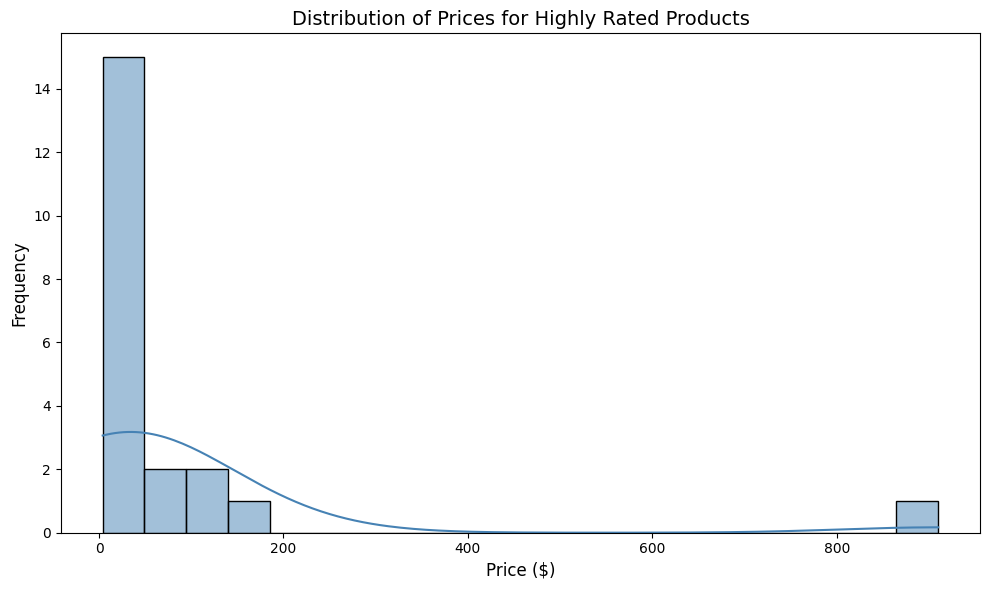

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1: Histogram of Product Prices
plt.figure(figsize=(10, 6))
sns.histplot(data=top_products_df, x='price', kde=True, bins=20, color='steelblue')
plt.title('Distribution of Prices for Highly Rated Products', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('histogram_prices.png', dpi=100, bbox_inches='tight')
plt.show()
print("Histogram saved as histogram_prices.png")

Scatterplot saved as scatterplot_price_rating.png


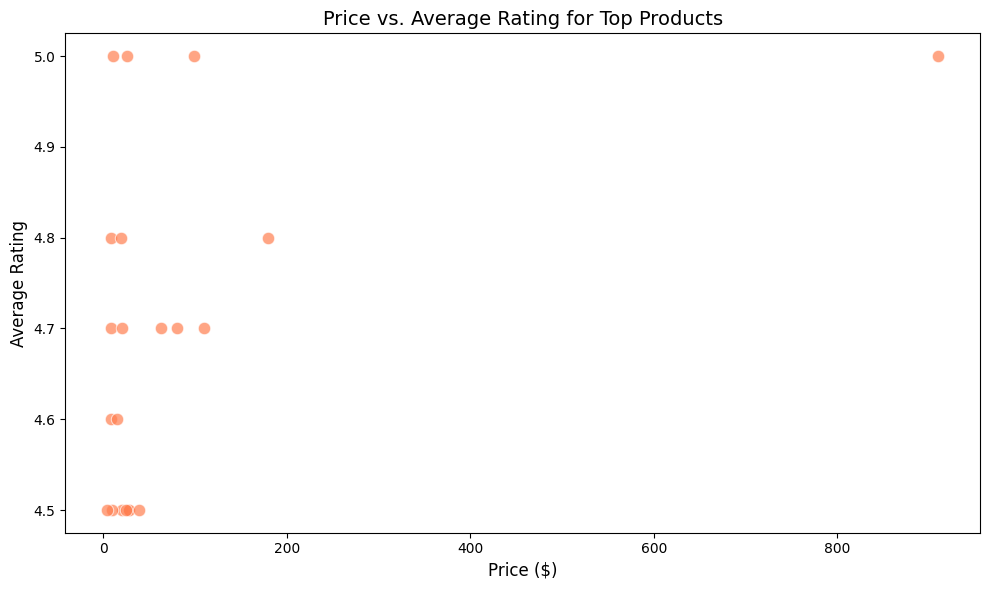

In [18]:
# 6.2: Scatterplot of Price vs Rating
plt.figure(figsize=(10, 6))
sns.scatterplot(data=top_products_df, x='price', y='average_rating',
                color='coral', alpha=0.7, s=80)
plt.title('Price vs. Average Rating for Top Products', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.tight_layout()
plt.savefig('scatterplot_price_rating.png', dpi=100, bbox_inches='tight')
plt.show()
print("Scatterplot saved as scatterplot_price_rating.png")

Combined dashboard saved as dashboard_combined.png


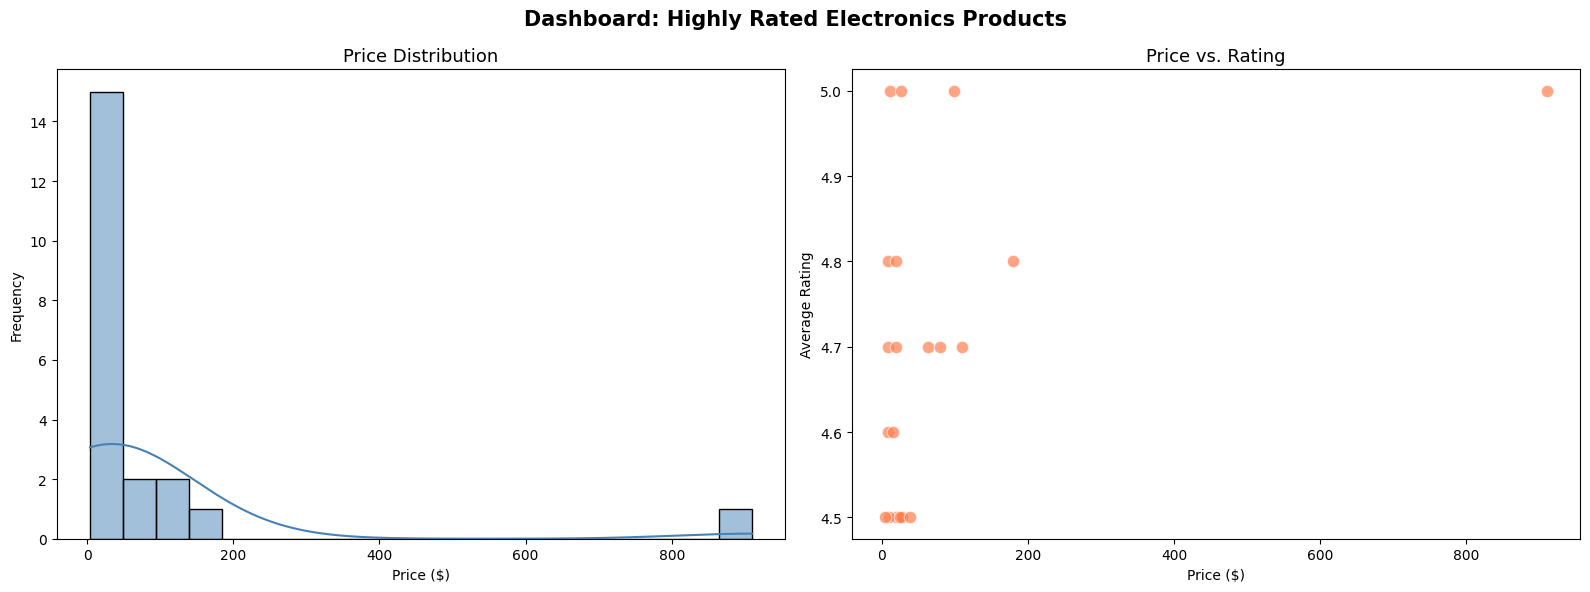

In [19]:
# 6.3: Combined histogram and scatterplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(data=top_products_df, x='price', kde=True, bins=20,
             color='steelblue', ax=axes[0])
axes[0].set_title('Price Distribution', fontsize=13)
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

# Scatterplot
sns.scatterplot(data=top_products_df, x='price', y='average_rating',
                color='coral', alpha=0.7, s=80, ax=axes[1])
axes[1].set_title('Price vs. Rating', fontsize=13)
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Average Rating')

plt.suptitle('Dashboard: Highly Rated Electronics Products', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard_combined.png', dpi=100, bbox_inches='tight')
plt.show()
print("Combined dashboard saved as dashboard_combined.png")

In [20]:
# 6.4: Filter with higher cutoff threshold
cutoff_threshold = 4.7

highly_rated_products_df = top_products_df[
    top_products_df['average_rating'] >= cutoff_threshold
].copy()

print(f"Products with rating >= {cutoff_threshold}: {len(highly_rated_products_df)}")
print(f"\nHighly Rated Products:")
highly_rated_products_df

Products with rating >= 4.7: 12

Highly Rated Products:


,title,average_rating,price
14,"Novelty Cute Cartoon USB 2.0 Flash Drive Data Storage Memory Stick Cartoon USB Stick Pendrive Gift (16GB, Camera Black)",4.7,8.98
16,"ANNKE 4K 16CH Security DVR Recorder with Human & Vehicle Detection and (16) 8MP Outdoor Bullet Cameras with IP67 Weatherproof, 100ft Night Vision with EXIR, Email Alert, NO Hard Drive",5.0,909.99
17,BIPRA U3 2.5 inch USB 3.0 NTFS Portable External Hard Drive - White (250GB),5.0,98.49
24,Polaroid Originals Now Viewfinder i-Type Instant Camera (White) Bundle with Color and B and W Instant Film and Reusable Vintage Photo Accessory (4 Items),4.8,179.99
30,HP Elitebook 8560W New Replacement LCD Screen for Laptop LED HD Matte,4.7,63.33
37,"Wenlaty Case Compatible with iPad 9th /8th /7th Generation Case(2021/2020/2019), Full Body Protective with Pencil Holder, Designed for iPad 10.2 Inch, Auto Sleep/Wake Cover, Sky Blue",4.7,19.99
42,Centon Electronics Flash Memory Card (S1-SDHU1-32G),4.8,8.99
46,"PNY 1TB PRO Elite Class 10 U3 V30 microSDXC Flash Memory Card - 100MB/s, Class 10, U3, V30, A2, 4K UHD, Full HD, UHS-I, micro SD",4.7,109.99
50,JBL FLIP 5 - Waterproof Portable Bluetooth Speaker Made from 100% Recycled Plastic - Blue (Renewed),4.7,79.90
60,"MHYALUDO Silicone Print Case Cover for Apple Airpods Pro 2nd Generation 2022 & 1st Generation 2019 Charging Case, Soft Earpods Case with keychain for Women with Airpods Pro Charging Case-White Leopard",5.0,10.99


=== Highly Rated Products (sorted by rating) ===
                                                                                                                                                                                                       title  average_rating   price
16                   ANNKE 4K 16CH Security DVR Recorder with Human & Vehicle Detection and (16) 8MP Outdoor Bullet Cameras with IP67 Weatherproof, 100ft Night Vision with EXIR, Email Alert, NO Hard Drive             5.0  909.99
17                                                                                                                               BIPRA U3 2.5 inch USB 3.0 NTFS Portable External Hard Drive - White (250GB)             5.0   98.49
60  MHYALUDO Silicone Print Case Cover for Apple Airpods Pro 2nd Generation 2022 & 1st Generation 2019 Charging Case, Soft Earpods Case with keychain for Women with Airpods Pro Charging Case-White Leopard             5.0   10.99
97                                 

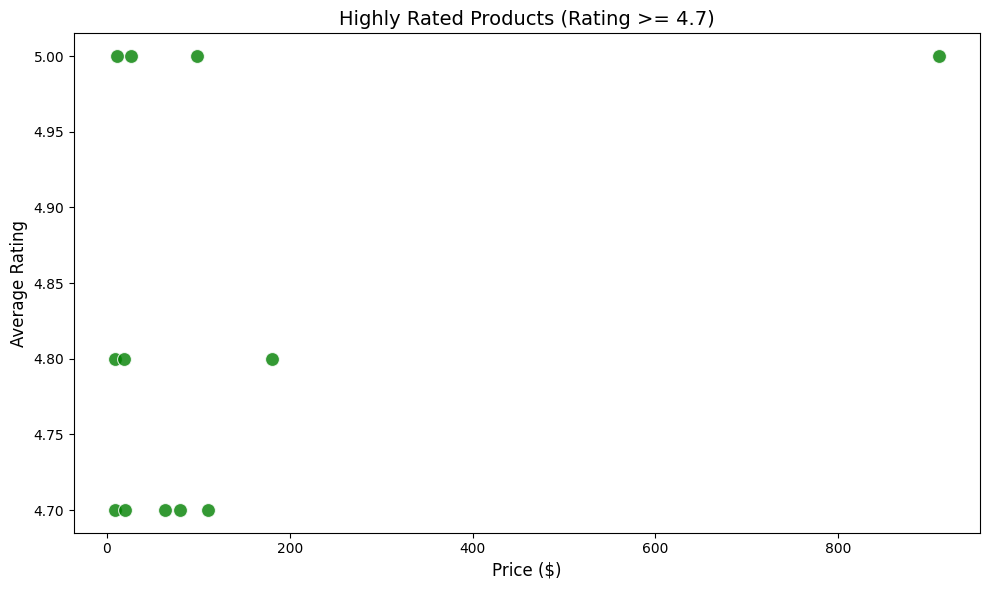

In [21]:
# 6.5: Dashboard with narrowed results
highly_rated_products_df_cutoff = 4.7

# Sort by average_rating descending
highly_rated_products_df = highly_rated_products_df.sort_values(
    by='average_rating', ascending=False
)

# Display sorted DataFrame
print("=== Highly Rated Products (sorted by rating) ===")
print(highly_rated_products_df.to_string())

# Create final scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=highly_rated_products_df,
    x='price',
    y='average_rating',
    color='green',
    s=100,
    alpha=0.8
)
plt.title(f'Highly Rated Products (Rating >= {highly_rated_products_df_cutoff})', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.tight_layout()
plt.savefig('highly_rated_dashboard.png', dpi=100, bbox_inches='tight')
plt.show()
print("Final dashboard saved as highly_rated_dashboard.png")

## Wrap Up
### Reflections and Conclusions

In [22]:
# Wrap-up: Export reflection answers
user_inputs = """\
=== PCEP Capstone Project: Reflection Questions ===
Project: A Data-Driven Approach to AI and Python
Transformational AI - Amazon Reviews Analysis

Q1: Which data analysis method was most helpful for you?
A1: The pandas DataFrame filtering and boolean indexing was the most helpful method.
It allowed me to efficiently clean and filter large datasets using conditions like
rating >= 4.5 and non-null prices, which directly reinforced the boolean logic and
comparison operators learned in the PCEP course.

Q2: How did exception handling help in this project?
A2: Exception handling with try-except blocks was crucial when working with the
metadata dataset. Some products had missing or non-numeric prices, and without
proper error handling, the program would crash. Using pd.to_numeric(errors='coerce')
combined with try-except ensured robust data processing.

Q3: How did loops reinforce your PCEP knowledge?
A3: For loops were used extensively - from loading dataset samples with a counter
and break statement, to iterating over DataFrame columns, to collecting top-rated
product titles with append(). This reinforced iteration concepts, loop control
(break/continue), and list building patterns from the course.

Q4: What Pythonic concepts from the PCEP course did you apply?
A4: Key concepts applied include:
- Variables and data types (int, float, str, bool)
- Boolean operators and comparison operators for filtering
- For loops with break for controlled iteration
- Functions with return statements (calculate_percentage)
- Exception handling with try-except blocks
- Lists and the append() method
- String formatting with f-strings

Q5: How would you explain this project in a portfolio context?
A5: This project demonstrates end-to-end data science workflow: loading large
datasets via streaming APIs, data cleaning and transformation with pandas,
statistical filtering, data export in multiple formats (CSV/Parquet), and
data visualization with matplotlib and seaborn. It showcases practical Python
skills applied to real-world Amazon product review analysis for ML model preparation.

Q6: What would you do differently or explore further?
A6: I would explore clustering products by price ranges, perform sentiment analysis
on review text, create heatmaps showing rating distribution across price brackets,
and investigate correlation between review count and average rating. Additionally,
I would expand the sample size beyond 100 items for more statistically significant results.
"""

# Save to file
with open('user_inputs.txt', 'w') as f:
    f.write(user_inputs.strip())

print("Reflection answers saved to user_inputs.txt")
print(f"File size: {os.path.getsize('user_inputs.txt')} bytes")

Reflection answers saved to user_inputs.txt
File size: 2491 bytes


In [23]:
# Final project summary
print("=" * 60)
print("  PCEP CAPSTONE PROJECT - COMPLETION SUMMARY")
print("=" * 60)
print(f"\n  Reviews loaded:        {len(reviews_df)} items")
print(f"  Metadata loaded:       {len(item_metadata_df)} items")
print(f"  Top products found:    {len(top_products_df)} items")
print(f"  Highly rated (>=4.7):  {len(highly_rated_products_df)} items")
print(f"  Data retained:         {percentage:.2f}%")
print(f"\n  Files exported:")
print(f"    \u2713 top_products.csv")
print(f"    \u2713 top_products.parquet")
print(f"    \u2713 user_inputs.txt")
print(f"    \u2713 PCEP_Capstone_Project.ipynb")
print(f"\n{'=' * 60}")
print("  Project completed successfully!")
print(f"{'=' * 60}")

  PCEP CAPSTONE PROJECT - COMPLETION SUMMARY

  Reviews loaded:        100 items
  Metadata loaded:       100 items
  Top products found:    21 items
  Highly rated (>=4.7):  12 items
  Data retained:         21.00%

  Files exported:
    ✓ top_products.csv
    ✓ top_products.parquet
    ✓ user_inputs.txt
    ✓ PCEP_Capstone_Project.ipynb

  Project completed successfully!
